# Quick analysis: PEVmean-GA vs random

This notebook gives a short comparison of `pevmean_ga` against `random_individual` from the latest run.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('../outputs/pevmean_ga/pevmean_ga_results.csv')
df = pd.read_csv(csv_path)
df.head()

,n_individuals,corr_eval,mse_adj,method,order_seed,pevmean_obj,target_island,target_island_name,repeat,repeat_seed,trait
0,500,0.222960,0.895013,pevmean_ga,-1,18719.066437,3,Selvær,0,261820732,body_mass
1,1000,0.245085,0.883797,pevmean_ga,-1,18290.733422,3,Selvær,0,261820732,body_mass
2,2000,0.192436,0.898875,pevmean_ga,-1,17669.872293,3,Selvær,0,261820732,body_mass
3,500,0.065708,0.921911,random_individual,0,NaN,3,Selvær,0,261820732,body_mass
4,1000,0.104769,0.918022,random_individual,0,NaN,3,Selvær,0,261820732,body_mass


In [3]:
summary = (
    df.groupby(['method', 'n_individuals'], as_index=False)
      .agg(
          corr_mean=('corr_eval', 'mean'),
          corr_std=('corr_eval', 'std'),
          mse_mean=('mse_adj', 'mean'),
          n_rows=('corr_eval', 'size')
      )
      .sort_values(['n_individuals', 'method'])
)
summary

,method,n_individuals,corr_mean,corr_std,mse_mean,n_rows
0,pevmean_ga,500,0.214219,0.037433,0.902543,5
3,random_individual,500,0.077572,0.043423,0.923075,25
1,pevmean_ga,1000,0.206289,0.054332,0.895041,5
4,random_individual,1000,0.112076,0.061828,0.916169,25
2,pevmean_ga,2000,0.204623,0.022023,0.902496,5
5,random_individual,2000,0.153187,0.046222,0.908265,25


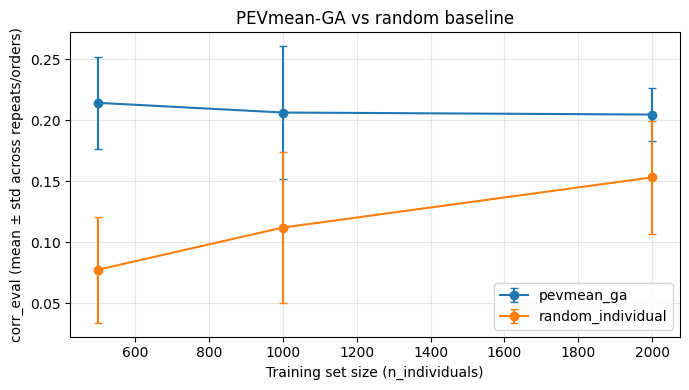

In [4]:
plot_df = summary.copy()
methods = plot_df['method'].unique().tolist()
x_vals = sorted(plot_df['n_individuals'].unique())

plt.figure(figsize=(7, 4))
for method in methods:
    sub = plot_df[plot_df['method'] == method].sort_values('n_individuals')
    plt.errorbar(
        sub['n_individuals'],
        sub['corr_mean'],
        yerr=sub['corr_std'].fillna(0.0),
        marker='o',
        capsize=3,
        label=method
    )

plt.xlabel('Training set size (n_individuals)')
plt.ylabel('corr_eval (mean ± std across repeats/orders)')
plt.title('PEVmean-GA vs random baseline')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
rand_mean = (
    df[df['method'] == 'random_individual']
    .groupby(['repeat', 'repeat_seed', 'n_individuals'], as_index=False)['corr_eval']
    .mean()
    .rename(columns={'corr_eval': 'corr_random_mean'})
)
ga = df[df['method'] == 'pevmean_ga'][['repeat', 'repeat_seed', 'n_individuals', 'corr_eval']].copy()
ga = ga.rename(columns={'corr_eval': 'corr_ga'})

cmp = ga.merge(rand_mean, on=['repeat', 'repeat_seed', 'n_individuals'], how='inner')
cmp['gain_vs_random_mean'] = cmp['corr_ga'] - cmp['corr_random_mean']

cmp_summary = (
    cmp.groupby('n_individuals', as_index=False)['gain_vs_random_mean']
       .agg(['mean', 'std', 'min', 'max'])
       .reset_index()
)
cmp_summary

,index,n_individuals,mean,std,min,max
0,0,500,0.136646,0.040727,0.094282,0.195420
1,1,1000,0.094213,0.071288,-0.010874,0.174716
2,2,2000,0.051436,0.038881,0.020423,0.116380
